In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.utils.data.dataloader as dataLoader

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
from IPython.display import clear_output

%matplotlib inline

In [18]:
batch_size = 64
num_epochs = 20
lr = 1e-4
data_set_root = "./data"

In [19]:
gpu_idx = 0
device = torch.device(gpu_idx if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## Create a transform for the input data

In [20]:
# transform.Compose will perfrom the transforms in order
# Resize and ToTensor will take in a PIL Image, Normalize takes in a Tensor
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize([0.1307], [0.308])
])

In [21]:
train_data = datasets.MNIST(data_set_root, train=True, download=True, transform=transform)
test_data = datasets.MNIST(data_set_root, train=False, download=True, transform=transform)

validation_split = 0.9

# Determine the number of samples for each split
n_train_examples = int(len(train_data) * validation_split)
n_valid_examples = len(train_data) - n_train_examples

train_data, valid_data = torch.utils.data.random_split(
    train_data, 
    [n_train_examples, n_valid_examples],
    generator=torch.Generator().manual_seed(42)
    )

In [22]:
print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(valid_data)}")
print(f"Test data size: {len(test_data)}")

Train data size: 54000
Validation data size: 6000
Test data size: 10000


In [23]:
train_dataloader = dataLoader.DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_dataloader = dataLoader.DataLoader(valid_data, batch_size=batch_size, shuffle=False)
test_dataloader = dataLoader.DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [26]:
class LeNet(nn.Module):
    def __init__(self, channels_in):
        super(LeNet, self).__init__()

        # conv1 6 channels_in 4x5 kernels
        self.conv1 = nn.Conv2d(channels_in, 6, kernel_size=5)
        # conv2 16 6x5x5 kernels
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        
        # maxpooling layers
        self.maxpool = nn.MaxPool2d(kernel_size=2)


        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # x shape is batchsize-3-32-32
        x = F.relu(self.conv1(x))
        # x shape is batchsize-6-28-28
        x = self.maxpool(x)
        # x shape is batchsize-6-14-14
        x = F.relu(self.conv2(x))
        # x shape is batchsize-16-10-10
        x = self.maxpool(x)
        # x shape is batchsize-16-5-5
        
        x = x.view(x.shape[0], -1)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [28]:
dataiter = iter(test_dataloader)
test_images, test_labels = next(dataiter)

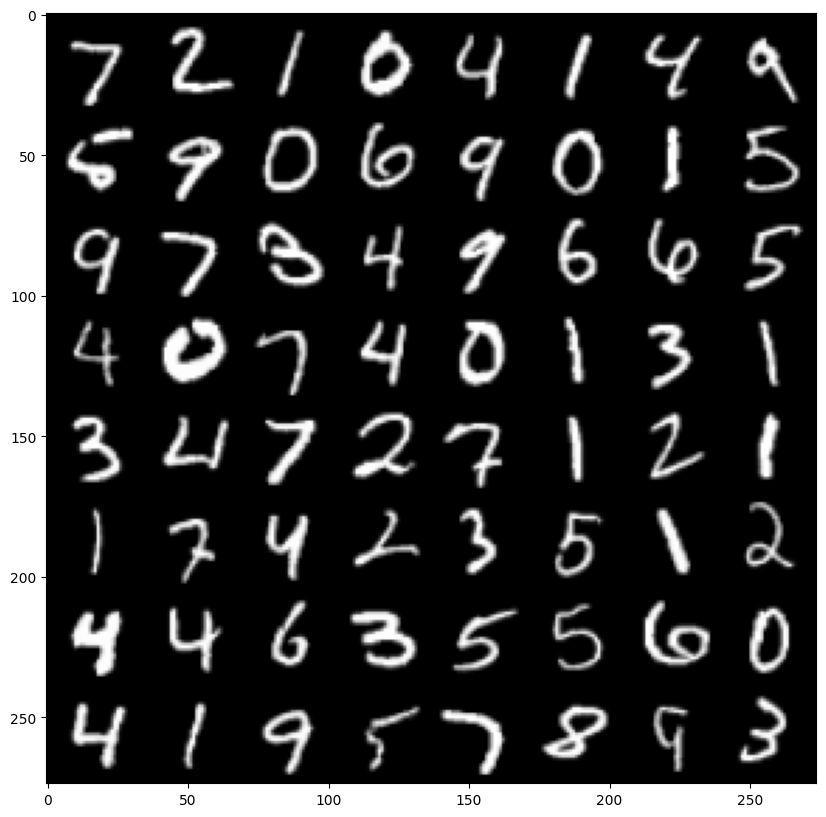

In [30]:
plt.figure(figsize=(20, 10))
out = torchvision.utils.make_grid(test_images, 8, normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))

In [31]:
model = LeNet(channels_in=test_images.shape[1]).to(device)
print(model)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [32]:
out = model(test_images.to(device))
out.shape

torch.Size([64, 10])

In [33]:
optimizer = optim.Adam(model.parameters(), lr=lr)

In [34]:
loss_fn = nn.CrossEntropyLoss()

In [35]:
def train(model, optimizer, loader, device, loss_fun, loss_logger):
    model.train()
    total_loss = 0.0
    for i, (x, y) in enumerate(tqdm(loader, desc="Training")):
        fx = model(x.to(device))
        loss = loss_fun(fx, y.to(device))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_logger.append(loss.item())

    return model, optimizer, loss_logger

In [ ]:
def evaluate(model, device, loader):
    epoch_acc = 0

    model.eval()

    with torch.no_grad():
        for i, (x, y) in enumerate(tqdm(loader, desc="Evaluating")):
            fx = model(x.to(device))
            epoch_acc += (fx.argmax(1) == y.to(device)).sum().item()

    return epoch_acc / len(loader.dataset)

In [40]:
training_loss_logger = []
validation_acc_logger = []
training_acc_logger = []

In [41]:
for epoch in trange(num_epochs, desc="Epochs", leave=False):
    model, optimizer, training_loss_logger = train(
        model, optimizer, train_dataloader, device, loss_fn, training_loss_logger
    )

    train_acc = evaluate(model, device, train_dataloader)
    valid_acc = evaluate(model, device, valid_dataloader)

    validation_acc_logger.append(valid_acc)
    training_acc_logger.append(train_acc)

print("Training complete!")

Evaluating: 100%|██████████| 94/94 [00:01<00:00, 65.75it/s]
                                                       

Training complete!


Text(0.5, 1.0, 'LeNet Training Loss')

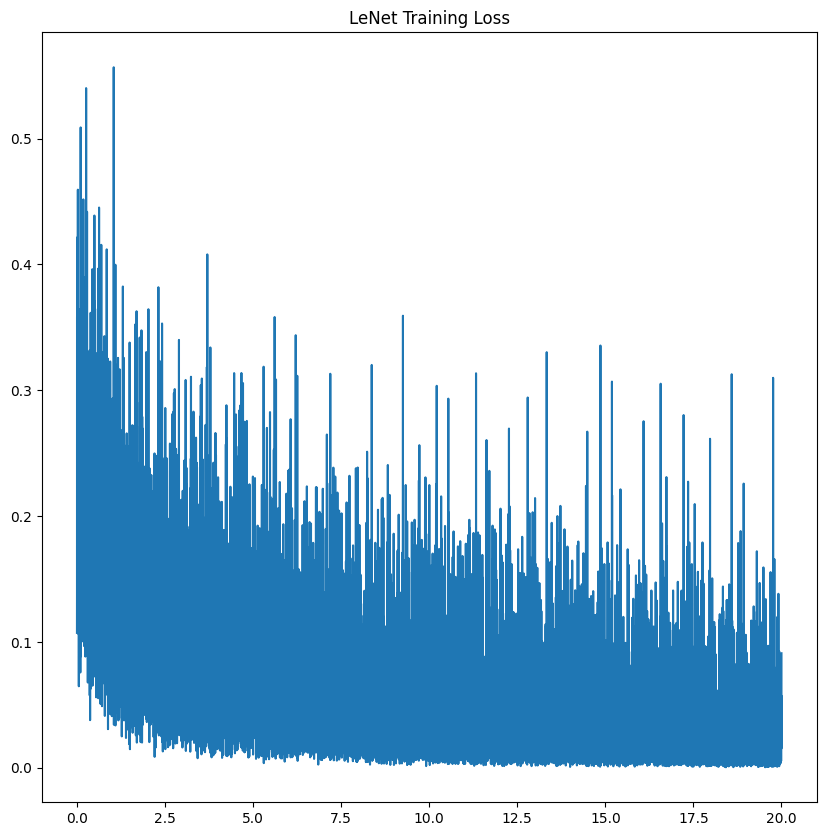

In [42]:
plt.figure(figsize=(10, 10))
train_x = np.linspace(0, num_epochs, len(training_loss_logger))
plt.plot(train_x, training_loss_logger)
plt.title("LeNet Training Loss")

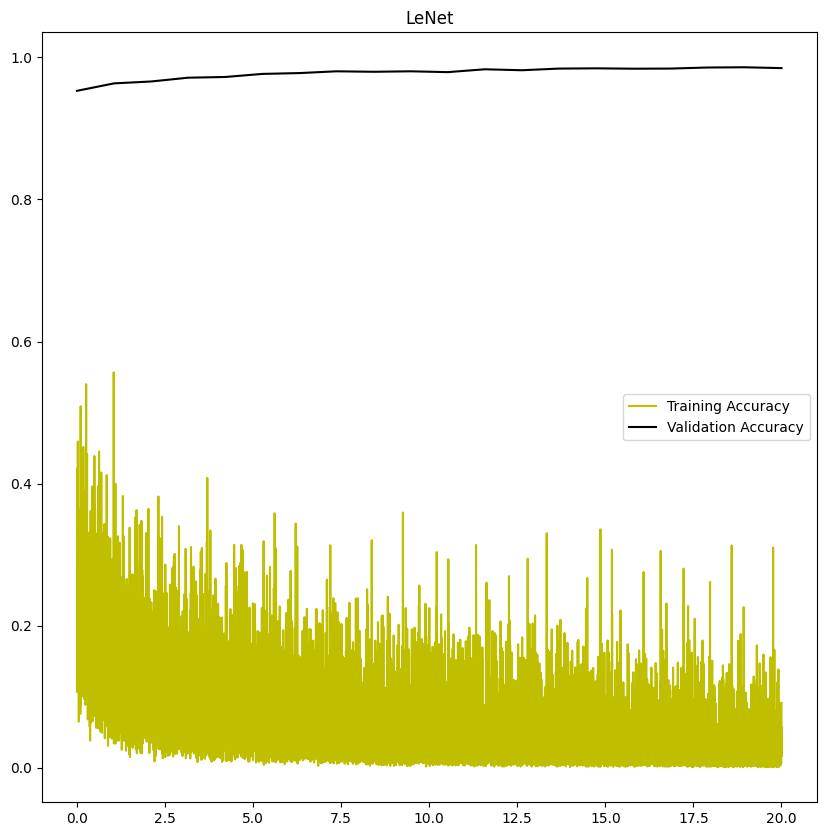

In [44]:
plt.figure(figsize=(10, 10))
train_x = np.linspace(0, num_epochs, len(training_loss_logger))
plt.plot(train_x, training_loss_logger, c="y")
valid_x = np.linspace(0, num_epochs, len(validation_acc_logger))
plt.plot(valid_x, validation_acc_logger, c="k")
plt.title("LeNet")
plt.legend(["Training Accuracy", "Validation Accuracy"])

In [45]:
# Call the evaluate function and pass the evaluation/test dataloader etc
test_acc = evaluate(model, device, test_dataloader)
print("The total test accuracy is: %.2f%%" %(test_acc*100))

Evaluating: 100%|██████████| 157/157 [00:02<00:00, 59.95it/s]

The total test accuracy is: 98.85%


Predicted Values
 [np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9)]
True Values
 [np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9)]


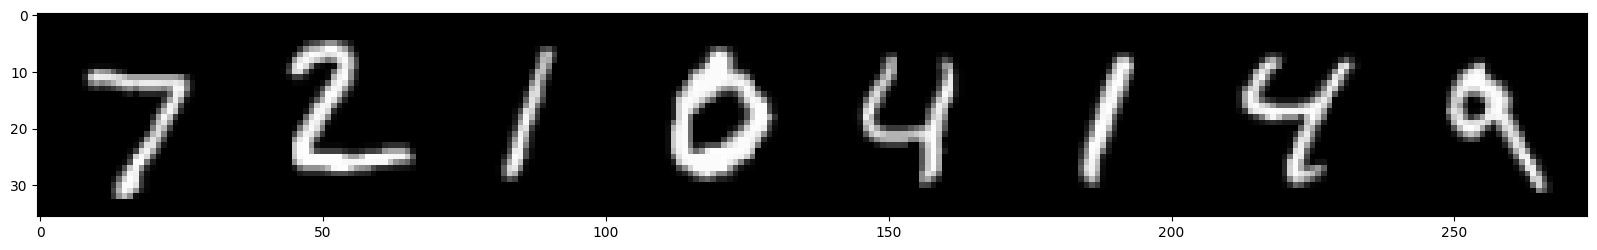

In [46]:
# Lets visualise the prediction for a few test images!

images_to_test = test_images[:8]
with torch.no_grad():
    # Forward pass of the images to test
    fx = model(test_images[:8].to(device))
    
    # Get the class indices
    class_pred = fx.argmax(-1)
    
plt.figure(figsize = (20,10))
out = torchvision.utils.make_grid(images_to_test, 8, normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))

print("Predicted Values\n", list(class_pred.cpu().numpy()))
print("True Values\n", list(test_labels[:8].numpy()))

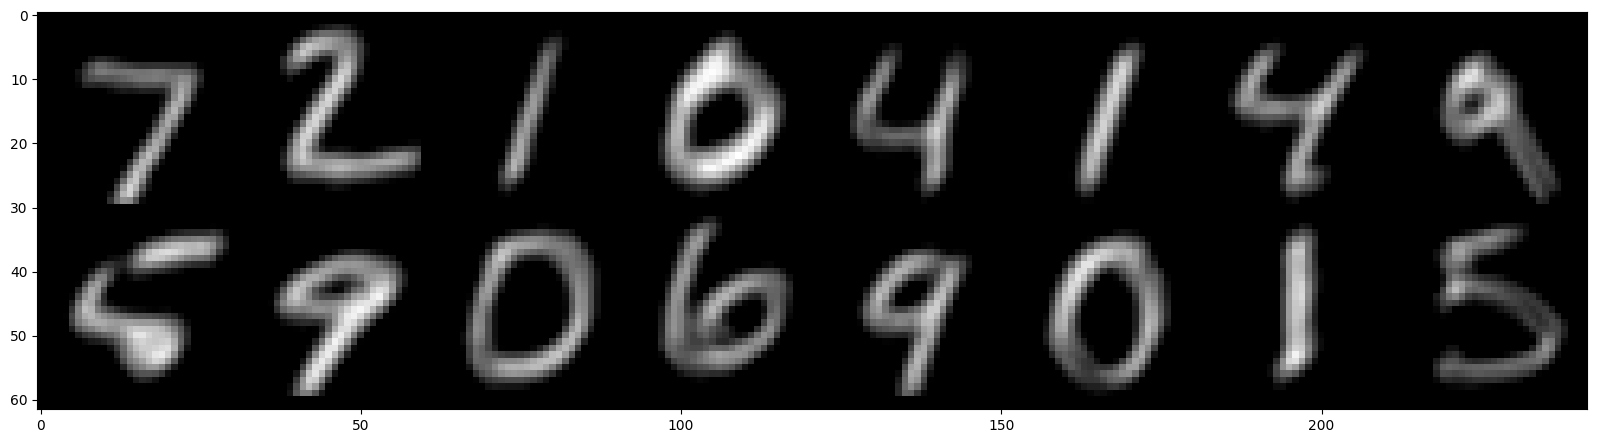

In [55]:
with torch.no_grad():
    model_out = F.relu(model.conv1(test_images.to(device)))

plt.figure(figsize=(20, 10))
out = torchvision.utils.make_grid(model_out[:16, 4].unsqueeze(1).detach().cpu(), 8, normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))

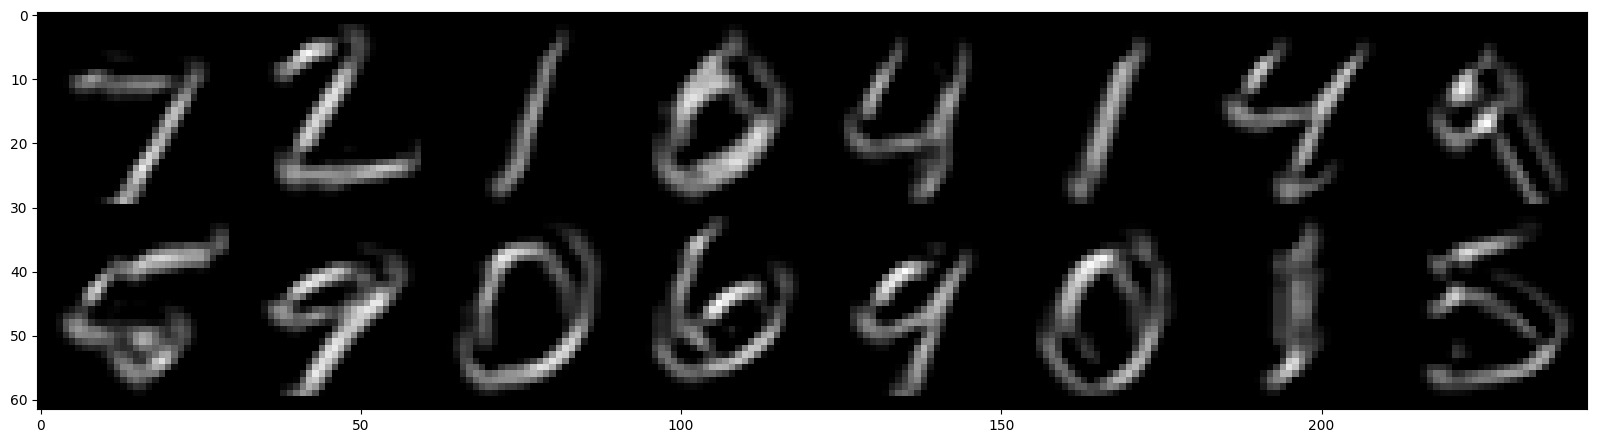

In [49]:
with torch.no_grad():
    model_out_2 = F.relu(model.conv1(test_images.to(device)))

plt.figure(figsize=(20, 10))
out = torchvision.utils.make_grid(model_out_2[:16, 0].unsqueeze(1).detach().cpu(), 8, normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))